<a href="https://www.kaggle.com/code/viktortaseski/diabetes-naive-bayes-and-ann?scriptVersionId=301786835" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
training_data = pd.read_csv("/kaggle/input/diabetes-dataset/Training.csv")
test_data = pd.read_csv("/kaggle/input/diabetes-dataset/Testing.csv")

# Data Analysis

In [3]:
training_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Here I just see the dataset's structure, types of attribute data and how the outcome is stored/interpreted.

In [4]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


### Note
Since all attributes are numeric, the Gaussian Naive Bayes classifier can be applied without discretization, while categorical Naive Bayes would require discretization of continuous variables.

In [5]:
training_data["Outcome"].value_counts()

Outcome
0    1500
1     960
Name: count, dtype: int64

### Note
1500 of the patients do not have diabetes and 960 do. This means that approximately **60% (3/5)** do not have diabetes and **40% (2/5)** do have it in this dataset. Predicting all to be **0 (no)** would give us **accuracy of 60%** but since it is more important to predict when the patient does have diabetes we should predict all to be **1 (yes)** thus giving us the minimal **accuracy of 40%**. Here I will try to beat that accuracy using **Naive Bayes** and **ANN**.

In [6]:
training_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,121.602033,68.915041,20.531301,80.119919,31.990447,0.491440,32.821951,0.390244
std,3.296458,31.789270,19.082655,15.716901,116.765807,7.802569,0.363917,11.251208,0.487904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.100000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,36.000000,32.100000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Note: Missing Values

Here we can notice that attributes: 
* glucose,
* bloodpressure,
* skinthickness,
* insulin and
* BMI

have min values of 0 which is impossible. This means we have missing values. Furthermore we can see that Q1 for SkinThickness and Insulin is 0 meaning that 25% of the values are missing.

(Pregnancies is not included since a person can have 0 pregnancises)

### Note: Something to consider (woman only dataset)

For attribute pregnancies we can see that Q2 is 3 meaning 50% of people have 3 or fewer pregnancies. This is further confirmed by the mean being 3.817. In real life the number of pregnancies per WOMAN is 1.38 in EU and 2.3 in the world. This dataset prioritizes on females with above average pregnancies. Also after some research I found that this is a women only dataset.

### Note: Outliers

Values like **BMI = 67** and **pregnancies=17** are outliers based on the IQR x 1.5 but they are medically possible. Same goes for the other max values of attributes. Therefore I will choose to leave this outliers and only deal with their missing values. But the **Insulin** and **DiabetesPedigreeFunction** have outliers that may influence the outcome. I will take care of them using the 99th percentile (values above 99th percentile are replaced with the 99th percentile).

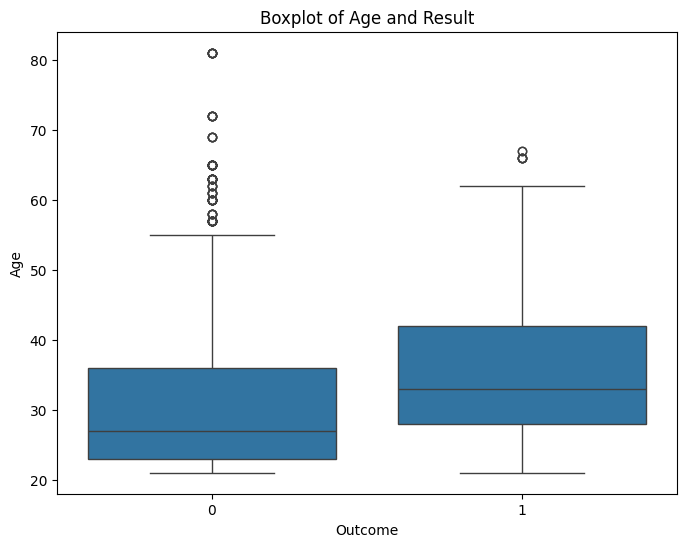

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Age', data=training_data)
plt.title('Boxplot of Age and Result')
plt.xlabel('Outcome')
plt.ylabel('Age')
plt.show()

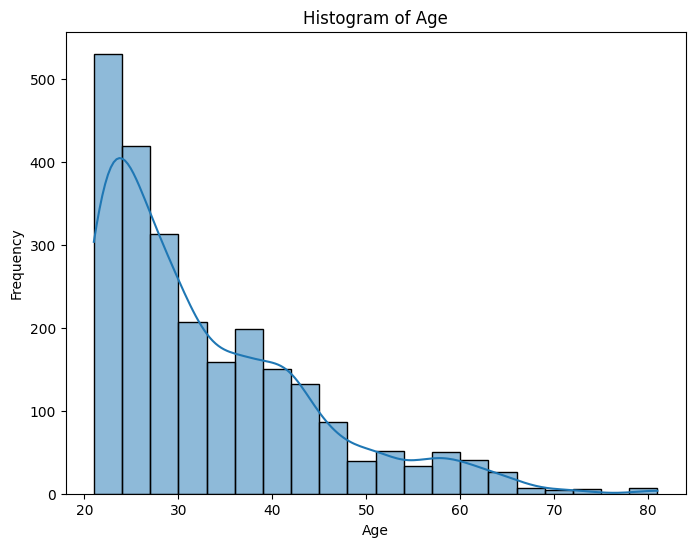

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(training_data['Age'], bins=20, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Note: Age related to outcome

Most of the patients that have diabetes are in the age group ~29 to ~43 (Group A). But majority of the patients are in the 20 to 30 age group (Group B). Even though Group B has less patients (historgram) the number of patients that are diabetics is greater. Therefore we can say that older people are more likely to have diabetes than younger people. We conclude that by the median of age for outcome=1 being higher than outcome=0.

# Data Preparation

In [9]:
training_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No actual missing values (like null), but as I said before there are some attributes where values are 0 (impossible/make no sense) incicating missing values.

In [10]:
cols_with_zero_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
training_data[cols_with_zero_missing] = training_data[cols_with_zero_missing].replace(0, np.nan)
test_data[cols_with_zero_missing] = test_data[cols_with_zero_missing].replace(0, np.nan)

Defining the features with zeros as an invalid value.

Replacing invalid zero values with missing values (NaN), and later choose a method to deal with missing values. (median vs. mean)

In [11]:
training_data[cols_with_zero_missing].isna().sum()

Glucose            17
BloodPressure     114
SkinThickness     717
Insulin          1181
BMI                31
dtype: int64

The results show that the attributes SkinThickness and Insulin contain a substantial amount of missing data, while Glucose, BloodPressure, and BMI have relatively few missing values. Due to the high proportion of missing values, removing rows is not appropriate, and imputation is required.


In [12]:
training_data[cols_with_zero_missing].skew()

Glucose          0.513264
BloodPressure    0.196328
SkinThickness    0.176772
Insulin          2.203221
BMI              0.545363
dtype: float64

## Data Preparation Plan


### **Imputation**

The approach I will use:
* Selective imputation based on distribution skewness:
    * Median imputation for skewed attributes
(because median is robust to outliers)
        * Pregnancies
        * Insulin 2.20 (strongly asymmetric)
        * Glucose 0.51 (moderately skewed)
        * BMI
        * DiabetesPedigreeFunction
        * Age
    * Mean imputation for approximately symmetric attributes
(because mean represents central tendency well)
        * BloodPressure → skew = 0.19
        * SkinThickness → skew = 0.17

Why I chose it:
* Insulin has many missing values and extreme outliers (median prevents distortion)
* Glucose and BMI show moderate skewness (median is safer)
* BloodPressure and SkinThickness are roughly symmetric (mean is appropriate)
* Dropping rows would remove too much data (imputation is required)

### **Outliers**
I will use the **99th percentile**, replacing all values of a feature that are above the 99th percentile with the 99th percentile.

Why I chose it:
* We keep all the rows
* Main issues were really high outliers
* IQR generally affects a larger range, potentially removing many valid high values


### **Standardization**

I will first convert all attribute values to float. Then I will use the **z-score standardization** {(x - mean) / std} formula on all attributes to reduce the difference between attribute ranges/values.

Why I chose it:
* ANN (Artificial Neural Network) models are sensitive to feature scale.
* Attributes like Glucose (0–200) and BMI (0–70) have much larger numeric ranges than features like DiabetesPedigreeFunction.
* Without scaling, features with larger magnitudes would dominate the gradient updates during backpropagation.

In [13]:
training_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2443.000000,2346.000000,1743.000000,1279.000000,2429.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,122.448219,72.263853,28.977051,154.100860,32.398724,0.491440,32.821951,0.390244
std,3.296458,30.231378,11.821553,10.189228,121.754763,6.958756,0.363917,11.251208,0.487904
min,0.000000,44.000000,30.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,21.000000,73.000000,27.300000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,30.000000,120.000000,32.300000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,36.000000,192.000000,36.600000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Missing values - Imputation

In [14]:
impute_vals = {
    "Insulin": training_data["Insulin"].median(),
    "Glucose": training_data["Glucose"].median(),
    "BMI": training_data["BMI"].median(),
    "BloodPressure": training_data["BloodPressure"].mean(),
    "SkinThickness": training_data["SkinThickness"].mean()
}


training_data.fillna(impute_vals, inplace=True)
test_data.fillna(impute_vals, inplace=True)
print("Train NaNs:", training_data.isna().sum().sum())
print("Test NaNs:", test_data.isna().sum().sum())

Train NaNs: 0
Test NaNs: 0


I use training_data medians and means on both datasets because all preprocessing parameters should be learned from training data only. (In real life we will not have the test dataset to compute them!)

In [15]:
training_data[cols_with_zero_missing].isna().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [16]:
training_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,122.410569,72.263853,28.977051,137.729675,32.397480,0.491440,32.821951,0.390244
std,3.296458,30.130078,11.544276,8.576026,89.414037,6.914762,0.363917,11.251208,0.487904
min,0.000000,44.000000,30.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,101.000000,64.000000,25.000000,119.000000,27.400000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.977051,120.000000,32.300000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


And just like that we can now see that we have no missing/invalid data in our dataset.

## Outliers - 99th percentile

In [17]:
clip_cols = ["Insulin", "DiabetesPedigreeFunction"]

p99_caps = training_data[clip_cols].quantile(0.99)

training_data[clip_cols] = training_data[clip_cols].clip(upper=p99_caps, axis=1)
test_data[clip_cols] = test_data[clip_cols].clip(upper=p99_caps, axis=1)

In [18]:
training_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,122.410569,72.263853,28.977051,136.485163,32.397480,0.487397,32.821951,0.390244
std,3.296458,30.130078,11.544276,8.576026,82.020172,6.914762,0.345441,11.251208,0.487904
min,0.000000,44.000000,30.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,101.000000,64.000000,25.000000,119.000000,27.400000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.977051,120.000000,32.300000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,543.820000,67.100000,1.893000,81.000000,1.000000


##  Standardization

Here I am standardizing the data because when we have an ANN and at the same time we deal with large numbers (or big ranges) the ANN seems to favor the features bigger values. That is why I use the formula of **(x - mean) / std** to reduce the gap between numbers and make all features contrubute on a more comparable scale. 

In [19]:
feature_cols = [c for c in training_data.columns if c != "Outcome"]

## Conversion to float
training_data = training_data.copy()
test_data = test_data.copy()
training_data[feature_cols] = training_data[feature_cols].astype(np.float64)
test_data[feature_cols] = test_data[feature_cols].astype(np.float64)

means = training_data[feature_cols].mean()
stds = training_data[feature_cols].std(ddof=0).replace(0, 1.0)

training_data[feature_cols] = (training_data[feature_cols] - means) / stds
test_data[feature_cols] = (test_data[feature_cols] - means) / stds

print(training_data[feature_cols].dtypes.unique())
print(test_data[feature_cols].dtypes.unique())

[dtype('float64')]
[dtype('float64')]


In [20]:
training_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2.460000e+03,2.460000e+03,2.460000e+03,2.460000e+03,2.460000e+03,2.460000e+03,2.460000e+03,2.460000e+03,2460.000000
mean,-3.610481e-18,1.270889e-16,4.765835e-16,-1.003714e-16,-1.877450e-16,-1.270889e-16,-1.270889e-16,1.104807e-16,0.390244
std,1.000203e+00,1.000203e+00,1.000203e+00,1.000203e+00,1.000203e+00,1.000203e+00,1.000203e+00,1.000203e+00,0.487904
min,-1.158291e+00,-2.602931e+00,-3.661767e+00,-2.563136e+00,-1.493658e+00,-2.053630e+00,-1.185385e+00,-1.050941e+00,0.000000
25%,-8.548730e-01,-7.107490e-01,-7.159855e-01,-4.638348e-01,-2.132246e-01,-7.228731e-01,-6.823016e-01,-7.842487e-01,0.000000
50%,-2.480377e-01,-1.796102e-01,-2.286042e-02,0.000000e+00,-2.010300e-01,-1.410020e-02,-3.080657e-01,-3.397616e-01,0.000000
75%,6.622151e-01,6.502942e-01,6.702646e-01,4.691878e-01,-9.127858e-02,5.934195e-01,4.621220e-01,5.492126e-01,1.000000
max,3.999809e+00,2.476084e+00,4.309171e+00,3.968023e+00,4.967286e+00,5.019634e+00,4.069843e+00,4.282904e+00,1.000000


## Classifier setup

In [21]:
X_train = training_data.drop(columns="Outcome")
Y_train = training_data["Outcome"]

X_test = test_data.drop(columns="Outcome")
Y_test = test_data["Outcome"]

ANNX_train = X_train
ANNY_train = Y_train
ANNX_test = X_test
ANNY_test = Y_test

In [22]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.662215,0.849471,-0.022860,0.702443,-0.201030,0.173942,0.404213,1.527084
1,-0.854873,-1.241888,-0.542704,0.002676,-0.201030,-0.838591,-0.394929,-0.161967
2,1.269050,2.011337,-0.715985,0.000000,-0.201030,-1.315928,0.534508,-0.073069
3,-0.854873,-1.109103,-0.542704,-0.697090,-0.518090,-0.621620,-0.927690,-1.050941
4,-1.158291,0.484313,-2.795361,0.702443,0.384311,1.548093,4.069843,0.015828


# Modeling

## Naive Bayes

In [23]:
from sklearn.naive_bayes import GaussianNB

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
bayes_model = GaussianNB()

### Note
Since we have mainly numeric values (measurements, continuous numeric data) and Multinomial NB features discrete counts here it is best to use the **Gaussian Naive Bayes**.


In [26]:
bayes_model.fit(X_train, Y_train)

GaussianNB()

In [27]:
Y_pred = bayes_model.predict(X_test)

## NB - Results

In [28]:
accuracy_score(Y_test, Y_pred)

0.762987012987013

Gaussian Naive Bayes 

|Gaussian|
|-----|
|0.762|
|0.766|
|0.769|

In [29]:
report = classification_report(Y_test, Y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.81      0.83       215
           1       0.60      0.66      0.63        93

    accuracy                           0.76       308
   macro avg       0.72      0.73      0.73       308
weighted avg       0.77      0.76      0.77       308



In [30]:
confusion_matrix(Y_test, Y_pred)

array([[174,  41],
       [ 32,  61]])

## NB - Conclusion

No matter the changes in data preparation phase the Gaussian NB gives the same accuracies on average. That is because unlike ANN, the Naive Bayes does not depend on distances so the scaling (standardization) does usually does not change much.

The Gaussian Naive Bayes classifier achieved an accuracy of approximately 77%, representing a substantial improvement over the Multinomial Naive Bayes model which I tested before that. The classifier performed well in identifying non-diabetic patients, achieving a precision of 0.85 and a recall of 0.81 for class 0. Importantly, performance for the diabetic class also improved, with a recall of 0.68, indicating that a significantly higher proportion of diabetic patients were correctly identified compared to the previous model and 0R.

The confusion matrix confirms this improvement, showing a reduction in false negatives from the Multinomial Naive Bayes model. Specifically, 63 diabetic patients were correctly classified, while 30 diabetic cases were misclassified, demonstrating better sensitivity to positive cases. Although some false negatives remain, the Gaussian Naive Bayes model provides a more balanced performance across both classes.

Overall, Gaussian Naive Bayes is more suitable for this dataset than the Multinomial, as it aligns with the continuous nature of the medical attributes and produces more reliable and clinically meaningful predictions.

## Artificial Neural Network

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LeakyReLU
from tensorflow.keras.optimizers import SGD

2026-03-06 11:56:37.673256: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772798197.857886      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772798197.908259      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772798198.371376      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772798198.371431      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772798198.371434      24 computation_placer.cc:177] computation placer alr

In [32]:
ANNX_train.shape

(2460, 8)

We start with 8 inputs (8 attributes)

In [33]:
ann_model = Sequential()
ann_model.add(Input((8,)))
ann_model.add(Dense(16, activation="elu"))
ann_model.add(Dense(32, activation="elu"))
ann_model.add(Dense(16, activation="elu"))
ann_model.add(Dense(1, activation="sigmoid"))

ann_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

ann_model.summary()

I0000 00:00:1772798210.255384      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,233 (4.82 KB)

 Non-trainable params: 0 (0.00 B)

The **Adam optimizer** was selected due to its adaptive learning rate and robust performance on tabular data. It provides fast and stable convergence without extensive hyperparameter tuning.


In [34]:
#class_weight = {
#    0: 1.0,
#    1: 1.2
#}

ann_model.fit(ANNX_train, ANNY_train, epochs=30, validation_split=0.2)

Epoch 1/30


I0000 00:00:1772798212.673737      66 service.cc:152] XLA service 0x7e8cbc00a8b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772798212.673767      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772798212.978460      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


51/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6720 - loss: 0.6130

I0000 00:00:1772798213.671804      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6799 - loss: 0.6026 - val_accuracy: 0.7236 - val_loss: 0.5021
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7259 - loss: 0.5170 - val_accuracy: 0.7419 - val_loss: 0.4935
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7283 - loss: 0.5159 - val_accuracy: 0.7459 - val_loss: 0.4891
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7339 - loss: 0.5019 - val_accuracy: 0.7520 - val_loss: 0.4846
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7555 - loss: 0.4822 - val_accuracy: 0.7541 - val_loss: 0.4873
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - loss: 0.4719 - val_accuracy: 0.7520 - val_loss: 0.4775
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7707 - loss: 0.4699 - val_accuracy: 0.7378 - val_loss: 0.4766
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4633 - val_accuracy: 0.7439 - val_loss: 0.4715
Ep

In [35]:
ANNY_pred = ann_model.predict(ANNX_test)
ANNY_pred = ANNY_pred > 0.5

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


## ANN - Results

In [36]:
accuracy_score(ANNY_test, ANNY_pred)

0.788961038961039

The purpose of this table was to track the changes and reflect how they influenced the accuracy.

The newer versions are largely the same as the previous ones, with only minor modifications. The key differences appear in the sections marked with bold version numbers. A bolded version number indicates a significant change, such as a different activation function, optimizer, or another major adjustment.

| Version | Model / changes | Accuracy 1 | Accuracy 2| Accuracy 3 |
|--------|--------|--------|--------|--------|
|**1**| SGD accuracy | 0.681| 0.720 |
|**2**| Adam | 0.649 | 0.714 |
|3| Adam Reduced | 0.733 | 0.766 |
|4| + standardization | 0.762 | 0.756 | 0.746 |
|5| + outliers | 0.775 | 0.766 | 0.779 |
|**6**| Imputation to all | 0.759 | 0.746 | 0.737 |
|7| Order swap | 0.759 | 0.746 | 0.737 |
|8| - Age, -DPF | 0.782 | 0.759 | 0.772 |
|**9**| LeakyRelu | 0.759 | 0.730 | 0.733 |
|**10**| elu | 0.801 | 0.782 | 0.805 |
|11| 99% + Preg | 0.782 | 0.792 | 0.782 |
|12| elu + class weight 1:2 | 0.769 | 0.730 | 0.762 |
|13| class weight 2:3 | 0.801 | 0.740 | 0.746 |
|14| class threshold >=0.5 | 0.750 | 0.724 | 0.714 |
|15| elu, threshold >0.5, weight=1:1.5| 0.779 | 0.727 | 0.766 |
|16| elu, no weight| 0.769 | 0.798 | 0.798 |

In [37]:
report = classification_report(ANNY_test, ANNY_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       215
           1       0.65      0.67      0.66        93

    accuracy                           0.79       308
   macro avg       0.75      0.75      0.75       308
weighted avg       0.79      0.79      0.79       308



| Model | Run 1 | Run 2|
--------|--------|--------|
|adam precision:| (0.85, 0.54) | (0.81, 0.52)|
|SGD precision:| (0.78, 0.54) | (0.78, 0.47)|
|Elu precision:| (0.86, 0.63) | (0.83, 0.65)|
|Weights precision:| (0.88, 0.54) | (0.83, 0.65)|



In [38]:
confusion_matrix(ANNY_test, ANNY_pred)

array([[181,  34],
       [ 31,  62]])

Although accuracy is important,the confusion matrix data below is of higher significance. We can see that we had an enormous change when we introduced Elu with standardization, 99th percentile and Imputation (versions: 4, 5 and 6).



**Initiall ANN**
* array([[195,  20],[ 61,  32]])

**Elu + (standardization, 99th percentile, Imputation)**
* array([[177,  32],[ 32,  61]])

**Elu + pregnancies added to 99th percentile**
* array([[178,  37],[ 29,  64]])

**Elu + class weights**
* array([[154,  61],[ 22,  71]]) 1:2
* array([[161,  54],[ 19,  74]]) 2:3
* array([[156,  59],[ 18,  75]]) 1:2 + threshold >=0.5
* array([[146,  69],[ 16,  77]]) 1:2 + threshold >=0.5
* array([[141,  74],[ 12,  81]]) threshold >=0.4

## ANN - Conclusion


#### What I found out

A **validation split** of 15-20% was shown to give the best results on this dataset. Because the data set is small (2460 rows) a 20% validation split gave us 492 rows to validate the predictions during training.

**Number of layers/ANN size**
When I tried the model (128-128-128) I noticed that the accuracy on the training dataset was 1.0, this told me that the model is memorizing the data (a pattern) and is not generalizing, that is why I have now reduced the model to (16-32-16). This change gave me an average of at least 72-73%. Also for smaller number of epochs the model performed better because it was generalizing and not memorizing like it was for epoch > 100.
Although the accuracy improved, the correctly guessed patients with diabetes stayed pretty much the same. So arguably this has no significant improvement since our goal is to predict the patients with diabetes.


**1. Standardization**

Standardizing the data lead to the ANN having more **consistent predictions**, thus **increasing the average accuracy** of the model. But what changed the most was the predicitons on outcome=1, they were almost opposite from before. By removing standardizing the data we achieved [29, 64] in the confusion matrix, where before that we had [61, 32]. So now the model improved in predicting (true positives) patients diagnosed with diabetes, which is our goal.


**2. Outliers**

Removing the outliers gave slightly better accuracy. No significant change worth noting.


**3. Activation Functions**

I have tried few activation functions but the ones that gave me the best accuracy were **elu** and **relu**. After standardization, many feature values become negative. Since Relu sets all negative inputs to zero, part of the information contained in those negative values is effectively discarded. In contrast, ELU allows small negative outputs, which helps preserve information and can improve gradient flow during training. This likely explains **elu's** better performance.

**4. Class weights**
When I introduced class weights a noticable improvement was seen on predicting patients with diabetes. On the other hand we lost on accuracy and the model started false predicting patients with diabetes more often. This was the case for the 1:2 ratio that I tried first. The ratio 2:3 gave me better accuracy, but the number of true positives decreased. Any other ratio above 1:2.3 gave me low accuracy and approximately the same true positives as 1:2 ratio of weights. If I had to choose I would either choose to have no weights at all, because the number of false positives almost doubles when we introduce weights. If not I would simply use the 1:2 or 1:1.2 ratios of class weights since they give us more true positives without losing a lot on accuracy.

**5. Classification threshold**
Initially the classification threshold was set to >0.5 (versions 1-13). Changing it to >= 0.5 gave us very little improvement on predicting true positives but lost us about 0.05 or 5% of accuracy on average. When the threshold was set to >=0.4 we had by far the best result of true positives however, we now had more than 1/3 of the non diabetic patients diagnosed with diabetes. Personally I think this is a bit too much and, we are losing out on accuracy too much.